# 1. Konfiguracja środowiska oraz datasetu

## 1.1. Instalacja zależności

In [11]:
#%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
#%pip install -r requirements.txt

## 1.2.Konfiguracja importów

In [12]:
import os
from pathlib import Path

import torch
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader

from src.dataset import GuitarSetDataset, BucketBatchSampler, collate_fn
from src.model import MultiTaskTranscriptionModel
from src.process_guitarset import process_dataset
from src.train import train_model
from src.validation import batch_validate
from src.visualization import plot_sample_data

os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

## 1.3. Konfiguracja GPU - automatyczne wykrywanie

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")
if device.type == 'cuda':
    print(f"Model karty GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True

Używane urządzenie: cuda
Model karty GPU: NVIDIA GeForce RTX 3070


## 1.4. Wczytanie guitarsetu

In [14]:
config = {
    "data_dir": "src/guitarset_data",
    "output_dir": "src/processed_data",
    "seed": 42,
    "max_tracks": None,
    "overwrite": False
}

process_dataset(**config)

Katalog wyjściowy src\processed_data istnieje i zawiera pliki .pt. Overwrite jest False. Pomijanie przetwarzania.


## 1.5. Wczytanie guitarseta z plików batch

In [15]:
# Wczytanie danych z plików
train_dir = Path(config["output_dir"]) / "train"
val_dir = Path(config["output_dir"]) / "val"
test_dir = Path(config["output_dir"]) / "test"

# Utworzenie datasetów
train_dataset = GuitarSetDataset(train_dir)
val_dataset = GuitarSetDataset(val_dir)
test_dataset = GuitarSetDataset(test_dir)

use_cuda = torch.cuda.is_available()
pin_memory = use_cuda
optimal_num_workers = 8

# Stworzenie samplera dla zbioru treningowego
train_batch_sampler = BucketBatchSampler(
    length_cache=train_dataset.lengths_cache,
    num_samples=len(train_dataset),
    batch_size=16,
    shuffle=True,
    drop_last=True
)

# Aktualizacja DataLoaderów
train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_batch_sampler,
    collate_fn=collate_fn,
    num_workers=optimal_num_workers,
    pin_memory=pin_memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=optimal_num_workers,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=optimal_num_workers,
    pin_memory=pin_memory
)

print("DataLoadery skonfigurowane.")
print(f"Używam GPU: {use_cuda}, pin_memory: {pin_memory}")
print(f"Liczba workerów: {optimal_num_workers}")

DataLoadery skonfigurowane.
Używam GPU: True, pin_memory: True
Liczba workerów: 8


## 1.6. Walidacja batcha


In [16]:
batch_validate(train_loader)

Pobieranie pierwszego batcha z DataLoader...
Klucze batcha: ['features', 'feature_lengths', 'notes', 'onsets', 'contours', 'mask']
Rozmiar batcha (na podstawie klucza 'features'): 16

--- Klucz: 'features' ---
  Typ danych (dtype): torch.float32
  Urządzenie (device): cpu
  Kształt tensora: torch.Size([16, 1879, 192])
  Wartość minimalna: -80.0000
  Wartość maksymalna: 0.0000
  Wartość średnia: -33.8387
  Fragment [0, 0, :10]: [-43.7918701171875, -44.05421447753906, -44.59453582763672, -46.885772705078125, -51.50379943847656, -73.37644958496094, -48.18439483642578, -39.861793518066406, -34.47030258178711, -30.05701446533203]

--- Klucz: 'feature_lengths' ---
  Typ danych (dtype): torch.int64
  Urządzenie (device): cpu
  Kształt tensora: torch.Size([16])
  Wartość minimalna: 621
  Wartość maksymalna: 1879
  Długości sekwencji: [1263, 1531, 997, 844, 1074, 1390, 885, 844, 1414, 954, 621, 1879, 1165, 844, 1088, 1546]
  Min/Max długość: 621 / 1879

--- Klucz: 'notes' ---
  Typ danych (dtyp

## 1.7. Wizualizacja przykładowego pliku

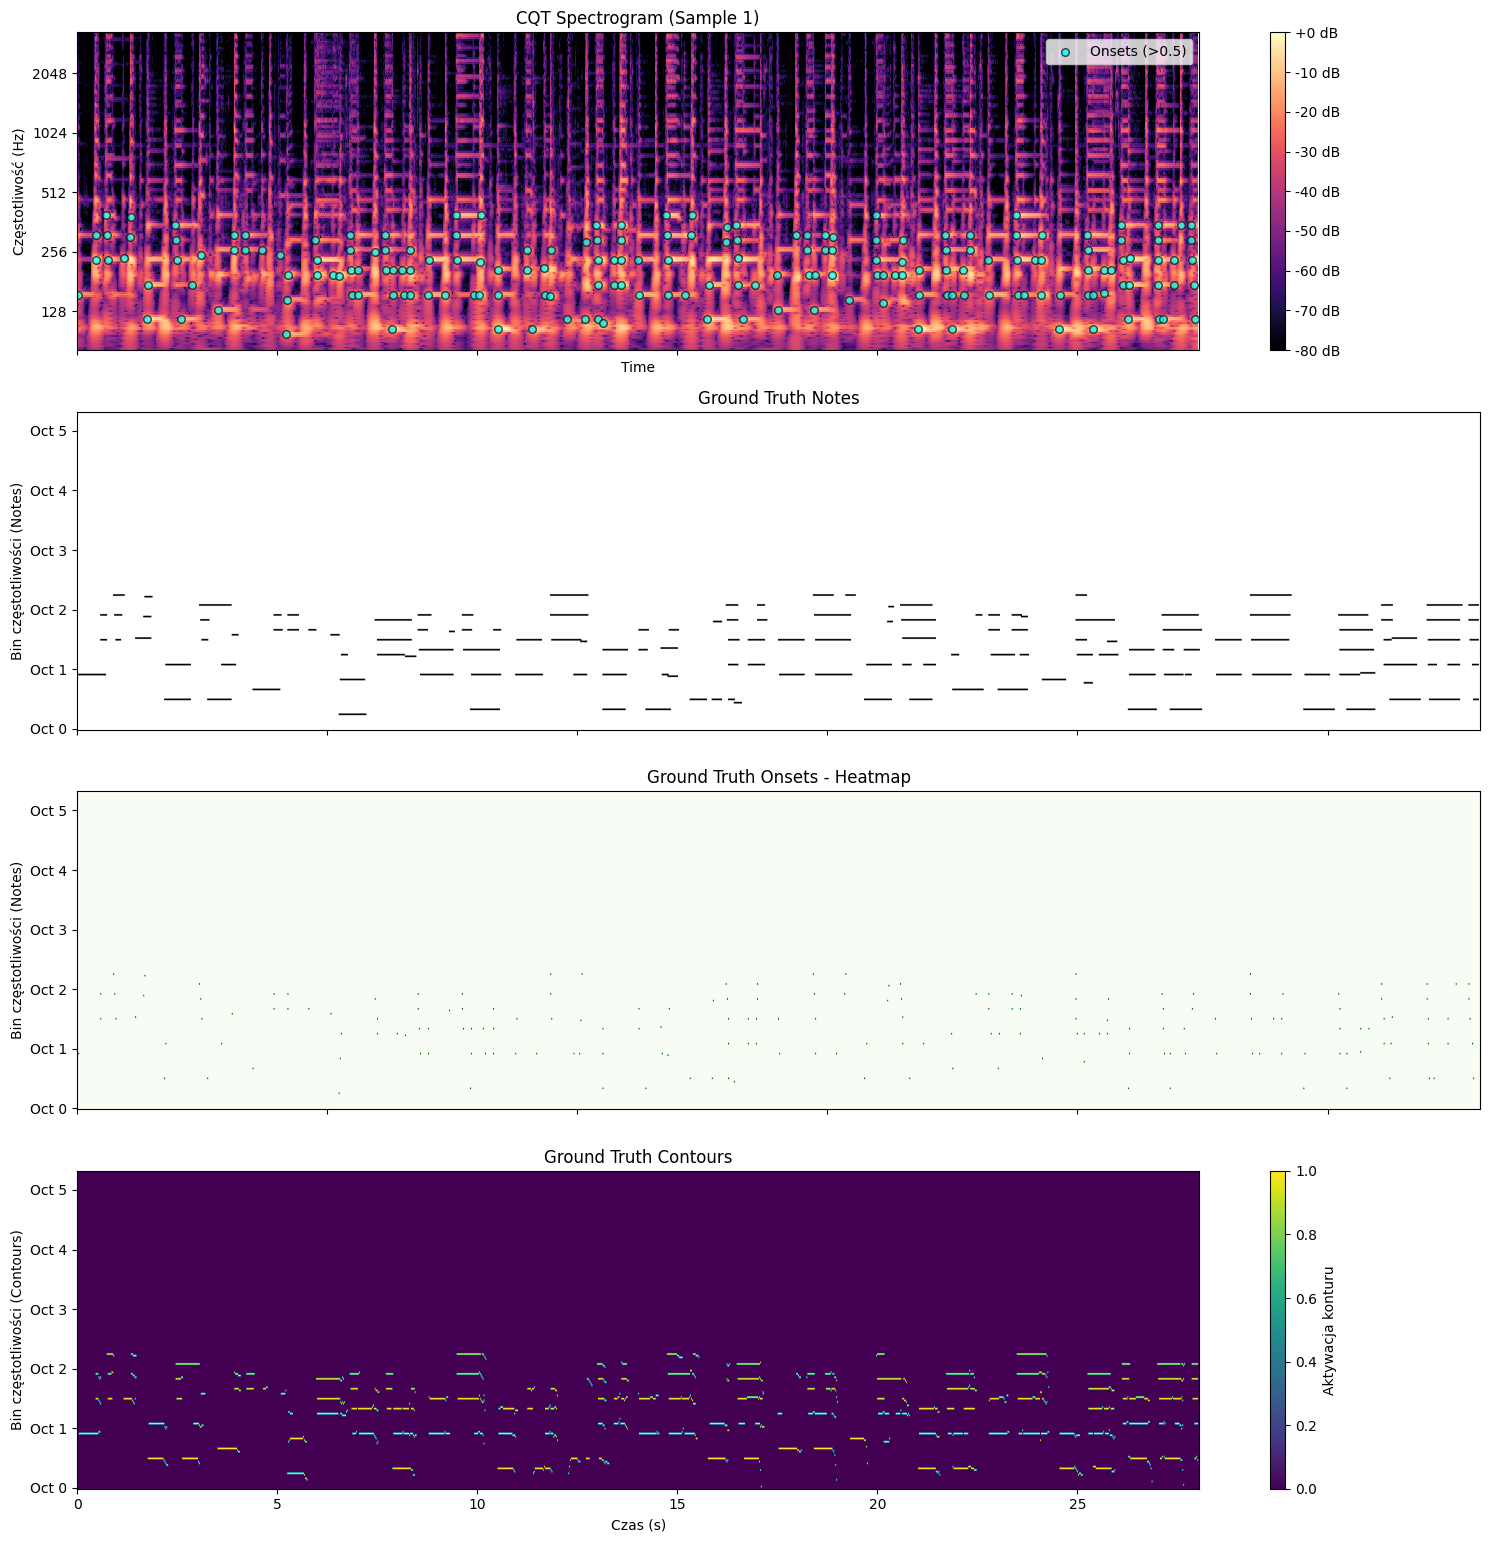

# Podstawowe sprawdzenia tensorów
  Kształt CQT (features): torch.Size([1207, 192])
  Kształt notes_target: torch.Size([1207, 192]), Min: 0.00, Max: 1.00, Niezerowe: 2534
  Kształt onsets_target: torch.Size([1207, 192]), Min: 0.00, Max: 1.00, Niezerowe: 184
  Kształt contours_target: torch.Size([1207, 192]), Min: 0.00, Max: 1.00, Niezerowe: 2319


In [17]:
sample_batch = next(iter(train_loader))
plot_sample_data(sample_batch, sample_idx=1)

# 2. Model i uczenie

## 2.1. Wczytanie implementacji modelu

In [18]:
model = MultiTaskTranscriptionModel()
model.to(device)

Inicjalizacja modelu. Wymiar wejściowy CQT (input_features): 192
Kształt wyjścia CNN (dla T=10): torch.Size([1, 64, 10, 48])
Obliczony rozmiar wejścia do RNN: 3072


MultiTaskTranscriptionModel(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.3, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.3, inplace=False)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=(1, 1), stride=(1, 1), padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.3, inplace=False)
  )
  (rnn): 

## 2.2. Konfiguracja treningu

In [19]:
from src.config import N_FREQ_BINS_NOTES, N_FREQ_BINS_CONTOURS
from src.losses import calculate_pos_weights_for_dataset

calculated_pos_weights = calculate_pos_weights_for_dataset(train_loader, device, N_FREQ_BINS_NOTES,
                                                           N_FREQ_BINS_CONTOURS)

POS_WEIGHTS_FOR_LOSS = calculated_pos_weights

Obliczanie wag pos_weight na podstawie zbioru treningowego...


100%|██████████| 17/17 [00:03<00:00,  4.48it/s]

Wagi dla notes: min=10.67, max=170.00, mean=138.26
Wagi dla onsets: min=167.71, max=170.00, mean=169.98
Wagi dla contours: min=12.90, max=170.00, mean=137.40


In [ ]:
LEARNING_RATE = 1e-3
NUM_EPOCHS = 4000
WEIGHT_DECAY = 1e-3
SCHEDULER_PATIENCE = 10
SCHEDULER_FACTOR = 0.4
GRADIENT_CLIP_VAL = 1.0
CHECKPOINT_DIR = "src/checkpoints"
MODEL_NAME = "best_model.pt"

TASK_WEIGHTS = {
    'notes': 0.9,
    'onsets': 9.5,
    'contours': 0.9
}

# --- Konfiguracja Early Stopping ---
EARLY_STOPPING_PATIENCE = 40
METRIC_FOR_CHECKPOINT = 'val_onsets_f1'

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=SCHEDULER_FACTOR, patience=SCHEDULER_PATIENCE)

training_history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    device=device,
    pos_weights=POS_WEIGHTS_FOR_LOSS,
    task_weights=TASK_WEIGHTS,
    gradient_clip_val=GRADIENT_CLIP_VAL,
    checkpoint_dir=CHECKPOINT_DIR,
    model_name=MODEL_NAME,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    metric_for_checkpoint=METRIC_FOR_CHECKPOINT
)

print("\nHistoria treningu (średnie straty i metryki F1 na zbiorze walidacyjnym):")
num_actual_epochs = len(training_history['train_loss'])
print(f"Trening trwał {num_actual_epochs} epok.")
if num_actual_epochs > 0:
    print(f"Ostatnia strata treningowa: {training_history['train_loss'][-1]:.4f}")
    print(f"Ostatnia strata walidacyjna: {training_history['val_loss'][-1]:.4f}")
    print(f"Ostatnie metryki walidacyjne:")

    print(
        f"  Notes:   F1={training_history['val_notes_f1'][-1]:.4f} (P={training_history['val_notes_precision'][-1]:.4f}, R={training_history['val_notes_recall'][-1]:.4f})")
    print(
        f"  Onsets:  F1={training_history['val_onsets_f1'][-1]:.4f} (P={training_history['val_onsets_precision'][-1]:.4f}, R={training_history['val_onsets_recall'][-1]:.4f})")
    print(
        f"  Contours:F1={training_history['val_contours_f1'][-1]:.4f} (P={training_history['val_contours_precision'][-1]:.4f}, R={training_history['val_contours_recall'][-1]:.4f})")


Rozpoczynanie treningu na max 4000 epok...
Logi TensorBoard do: src\checkpoints\logs\best_model

--- Epoch 1/4000 ---


Generowanie wizualizacji dla epoki 1...
Wykres zapisany do: src\checkpoints\plots\best_model\epoch_1_sample_0.png
Wizualizacja zapisana w src\checkpoints\plots\best_model\epoch_1_sample_0.png
  Val Loss:   3.7950 (N: 0.6052, O: 0.2693, C: 0.7019)
  Val Metrics: Note F1=0.0585 (P=0.0309, R=0.5506, AUC-PR=0.0296)
               Onset F1=0.0097 (P=0.0050, R=0.2293, AUC-PR=0.0053)
               Contour F1=0.0452 (P=0.0235, R=0.6313, AUC-PR=0.0235)
  Poprawa metryki 'val_onsets_f1': 0.0097. Zapisywanie modelu do src\checkpoints\best_model.pt...
  Czas trwania epoki: 144.65s

--- Epoch 2/4000 ---


  Val Loss:   3.7504 (N: 0.6006, O: 0.2654, C: 0.6980)
  Val Metrics: Note F1=0.0700 (P=0.0370, R=0.6593, AUC-PR=0.0355)
               Onset F1=0.0132 (P=0.0068, R=0.1803, AUC-PR=0.0061)
               Contour F1=0.0521 (P=0.0271, R=0.6521, AUC-PR=0.0262)
  Poprawa metryki 'val_onsets_f1': 0.0132. Zapisywanie modelu do src\checkpoints\best_model.pt...
  Czas trwania epoki: 157.02s

--- Epoch 3/4000 ---


  Val Loss:   3.7761 (N: 0.5973, O: 0.2670, C: 0.7132)
  Val Metrics: Note F1=0.0422 (P=0.0224, R=0.3693, AUC-PR=0.0247)
               Onset F1=0.0097 (P=0.0050, R=0.1326, AUC-PR=0.0059)
               Contour F1=0.0406 (P=0.0213, R=0.4213, AUC-PR=0.0195)
  Brak poprawy metryki 'val_onsets_f1' przez 1 epok.
  Czas trwania epoki: 124.07s

--- Epoch 4/4000 ---


  Val Loss:   3.5443 (N: 0.6146, O: 0.2410, C: 0.7109)
  Val Metrics: Note F1=0.0615 (P=0.0331, R=0.4422, AUC-PR=0.0344)
               Onset F1=0.0320 (P=0.0167, R=0.3820, AUC-PR=0.0114)
               Contour F1=0.0479 (P=0.0254, R=0.4375, AUC-PR=0.0244)
  Poprawa metryki 'val_onsets_f1': 0.0320. Zapisywanie modelu do src\checkpoints\best_model.pt...
  Czas trwania epoki: 129.04s

--- Epoch 5/4000 ---


...

  Val Loss:   2.8537 (N: 0.5991, O: 0.1718, C: 0.6920)
  Val Metrics: Note F1=0.0809 (P=0.0430, R=0.6916, AUC-PR=0.0464)
               Onset F1=0.0265 (P=0.0135, R=0.7195, AUC-PR=0.0231)
               Contour F1=0.0599 (P=0.0313, R=0.6959, AUC-PR=0.0307)
  Brak poprawy metryki 'val_onsets_f1' przez 2 epok.
  Czas trwania epoki: 160.95s

--- Epoch 8/4000 ---


  Val Loss:   2.8420 (N: 0.5992, O: 0.1705, C: 0.6924)
  Val Metrics: Note F1=0.0747 (P=0.0395, R=0.6690, AUC-PR=0.0357)
               Onset F1=0.0266 (P=0.0135, R=0.7437, AUC-PR=0.0236)
               Contour F1=0.0529 (P=0.0276, R=0.6714, AUC-PR=0.0242)
  Brak poprawy metryki 'val_onsets_f1' przez 3 epok.
  Czas trwania epoki: 166.16s

--- Epoch 9/4000 ---


  Val Loss:   2.6691 (N: 0.5713, O: 0.1575, C: 0.6689)
  Val Metrics: Note F1=0.0722 (P=0.0391, R=0.4645, AUC-PR=0.0355)
               Onset F1=0.0312 (P=0.0159, R=0.7331, AUC-PR=0.0279)
               Contour F1=0.0504 (P=0.0271, R=0.3620, AUC-PR=0.0280)
  Brak poprawy metryki 'val_onsets_f1' przez 4 epok.
  Czas trwania epoki: 164.82s

--- Epoch 10/4000 ---


Generowanie wizualizacji dla epoki 10...
Wykres zapisany do: src\checkpoints\plots\best_model\epoch_10_sample_0.png
Wizualizacja zapisana w src\checkpoints\plots\best_model\epoch_10_sample_0.png
  Val Loss:   2.7074 (N: 0.5594, O: 0.1644, C: 0.6513)
  Val Metrics: Note F1=0.0736 (P=0.0389, R=0.6919, AUC-PR=0.0380)
               Onset F1=0.0259 (P=0.0132, R=0.7857, AUC-PR=0.0296)
               Contour F1=0.0590 (P=0.0309, R=0.6530, AUC-PR=0.0296)
  Brak poprawy metryki 'val_onsets_f1' przez 5 epok.
  Czas trwania epoki: 166.55s

--- Epoch 11/4000 ---


Training:  53%|█████▎    | 9/17 [02:09<01:51, 13.93s/it]